Import Libraries

In [ ]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

Use GPU if available

In [ ]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda


Load dataset

Shuffle the original training split reproducibly,
then select 10,000 examples.

In [ ]:



raw_data = load_dataset("stanfordnlp/imdb")


selected_train = raw_data["train"].shuffle(seed=42).select(range(10000))


#the actual comments.
texts = selected_train["text"]

# positive or negative review
labels = selected_train["label"]


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
texts[0]


'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...'

In [ ]:
labels[0]

1

This counts how many positive and negative reviews are in your selected 10,000 examples.

- 5004 reviews are positive
- 4996 are negative

In [ ]:

print(Counter(labels))

Counter({0: 5004, 1: 4996})


Clean and Tokenize


We perform three simple preprocessing steps:

Convert text to lowercase.
Remove punctuation.
Split into words


In [ ]:
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.split()

tokenized_texts = [clean_and_tokenize(t) for t in texts]

Build vocabulary

In [ ]:


n_total = len(tokenized_texts) # Stores total number of reviews


train_size = int(0.8 * n_total) # This calculates 80% of the data for training


g = torch.Generator().manual_seed(42) # This creates a random-number generator with seed 42.


perm = torch.randperm(n_total, generator=g).tolist() #  creates a random ordering of all indexes from 0 to 9999


train_idx, val_idx = perm[:train_size], perm[train_size:]

VOCAB_SIZE = 10000
MAX_LEN = 256


PAD_TOKEN = "<PAD>"  # fills unused positions in short reviews.


UNK_TOKEN = "<UNK>" # represents words that are not included in the vocabulary

train_tokens = [tokenized_texts[i] for i in train_idx]

all_words = [
    word
    for tokens in train_tokens
    for word in tokens
    ]

word_counts = Counter(all_words)

most_common = word_counts.most_common(VOCAB_SIZE - 2)

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for word, _ in most_common:
    vocab[word] = len(vocab)

# Convert words to integers
def encode(tokens, vocab):
    return [vocab.get(word, vocab[UNK_TOKEN]) for word in tokens]

# This function ensures every encoded review has the same length.
def pad_sequence(ids, max_len, pad_idx=0):
    if len(ids) < max_len:
        return ids + [pad_idx] * (max_len - len(ids)), len(ids)
    else:
        return ids[:max_len], max_len

encoded_sequences = []
lengths = []

for tokens in tokenized_texts:
    ids, true_len = pad_sequence(
        encode(tokens, vocab),
        MAX_LEN,
        vocab[PAD_TOKEN])

    encoded_sequences.append(ids)
    lengths.append(max(true_len, 1))

In [ ]:
print("Number of reviews:", len(encoded_sequences))
print("Length of first review:", len(encoded_sequences[0]))
print("First 20 token IDs:", encoded_sequences[0][:20])
print("Vocabulary size:", len(vocab))

Number of reviews: 10000
Length of first review: 256
First 20 token IDs: [47, 7, 58, 4549, 31, 30, 203, 1, 3, 1, 18, 2, 190, 12, 186, 23, 502, 205, 42, 1056]
Vocabulary size: 10000


Create the custom dataset

PyTorch Dataset for encoded IMDb reviews.
label: sentiment label, 0 or 1

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, lengths, labels):

      # This converts the encoded reviews into a PyTorch tensor.
        self.sequences = torch.tensor(
          sequences,
          dtype=torch.long)
         # This converts the true review lengths into a tensor.
        self.lengths = torch.tensor(
            lengths,
            dtype=torch.long
            )

        # This converts the labels into floating-point values
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )

full_dataset = IMDBDataset(
    encoded_sequences,
    lengths,
    labels)

# Train and validation split

Split the data into 8,000 training samples and 2,000 validation samples.

In [ ]:


train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Use a fixed seed so that the split is reproducible.
split_generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 8000
Validation samples: 2000



# Create a Dataloader

This takes the dataset and serves it to the model in batches

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 125
Validation batches: 32


# Define the model architecture

In [ ]:


class SentimentLSTM(nn.Module):
    """
    LSTM model for binary sentiment classification.
    """

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=64,
        num_layers=2,
        dropout=0.5,
        pad_idx=0
    ):
        super().__init__()

        # Convert each token ID into a dense vector.

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx)


        # Process the sequence of word embeddings.
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Reduce overfitting before classification.
        self.dropout = nn.Dropout(dropout)

        # Produce one output value for binary classification.
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, text, lengths):
        """
        text shape:
            [batch_size, sequence_length]

        Returns:
            logits shape:
            [batch_size]
        """

        # embedded shape:
        # [batch_size, sequence_length, embedding_dim]
        embedded = self.embedding(text)

        packed = pack_padded_sequence(
            embedded, lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, cell) = self.lstm(packed)

        # Concatenate top-layer forward state (hidden[-2]) and backward state (hidden[-1])
        last_output = torch.cat((hidden[-2], hidden[-1]), dim=1)



        dropped_output = self.dropout(last_output)

        logits = self.fc(dropped_output)

        return logits.squeeze(1)


Create the model

In [ ]:
model = SentimentLSTM(
    vocab_size=len(vocab),
    embedding_dim=200,
    hidden_dim=256,
    num_layers=2,
    dropout=0.5,
    pad_idx=vocab[PAD_TOKEN]
)

model = model.to(device)

print(model)

SentimentLSTM(
  (embedding): Embedding(10000, 200, padding_idx=0)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


Define loss function and optimizer

BCEWithLogitsLoss combines the sigmoid operation with binary cross-entropy in a numerically stable way

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence

# Create the training function

In [ ]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for sequences, lengths, labels in data_loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)  # CHANGED

        optimizer.zero_grad()
        outputs = model(sequences, lengths)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()


        total_loss += loss.item() * sequences.size(0)
        predictions = (torch.sigmoid(outputs) >= 0.5).float()
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)
    return total_loss / total_samples, total_correct / total_samples


Validation function

In [ ]:

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)  # CHANGED
            outputs = model(sequences, lengths)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * sequences.size(0)
            predictions = (torch.sigmoid(outputs) >= 0.5).float()
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
    return total_loss / total_samples, total_correct / total_samples

Train the model

In [ ]:
NUM_EPOCHS = 5

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    val_loss, val_accuracy = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )



    # Store metrics for future plots.
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Save the model whenever validation accuracy improves.
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_sentiment_lstm.pt"
        )

        saved_message = " - saved best model"
    else:
        saved_message = ""

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
        f"{saved_message}"
    )

Epoch 1/5 | Train Loss: 0.6900 | Train Acc: 0.5395 | Val Loss: 0.6869 | Val Acc: 0.5670 - saved best model
Epoch 2/5 | Train Loss: 0.6531 | Train Acc: 0.6306 | Val Loss: 0.6305 | Val Acc: 0.6425 - saved best model
Epoch 3/5 | Train Loss: 0.5413 | Train Acc: 0.7230 | Val Loss: 0.5510 | Val Acc: 0.7220 - saved best model
Epoch 4/5 | Train Loss: 0.4533 | Train Acc: 0.7881 | Val Loss: 0.4862 | Val Acc: 0.7645 - saved best model
Epoch 5/5 | Train Loss: 0.4006 | Train Acc: 0.8215 | Val Loss: 0.4742 | Val Acc: 0.7845 - saved best model


Plot training and validation loss

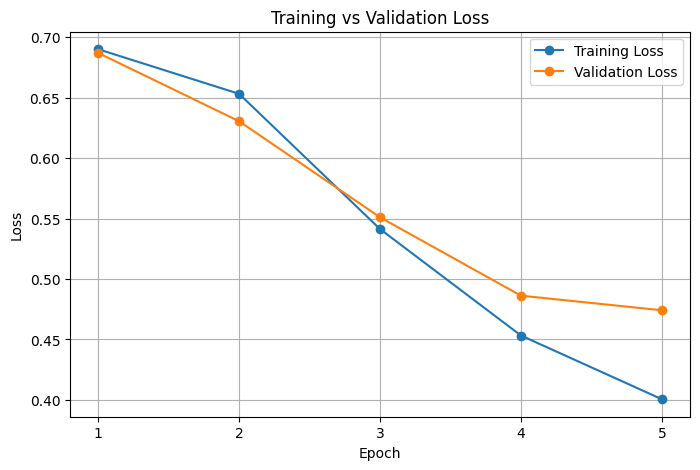

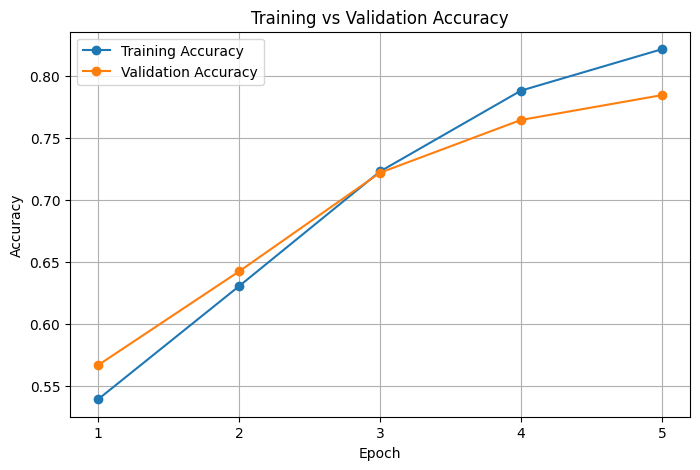

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()


# Training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

Final Model Evualuation

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

#  Load the best saved model weights
model.load_state_dict(torch.load("best_sentiment_lstm.pt"))
model.eval()

all_preds = []
all_labels = []

# Gather predictions on the validation set
with torch.no_grad():
    for sequences, lengths, labels in val_loader:
        sequences, lengths = sequences.to(device), lengths.to(device)
        outputs = model(sequences, lengths)

        preds = (torch.sigmoid(outputs) >= 0.5).float().cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# 3. Calculate metrics
acc = (np.array(all_preds) == np.array(all_labels)).mean()
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)


print("FINAL MODEL EVALUATION METRICS")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


FINAL MODEL EVALUATION METRICS
Accuracy:  0.7845
Precision: 0.7644
Recall:    0.8104
F1 Score:  0.7867


Confusion Matrix

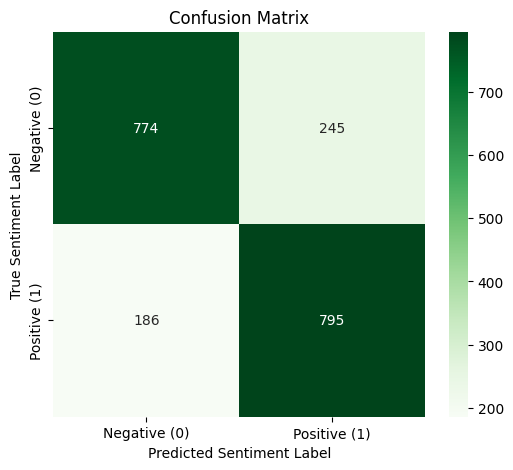

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment Label")
plt.ylabel("True Sentiment Label")
plt.show()